# **Diplomado IA: Inteligencia Artificial II - Métodos de Profundización**. <br> Práctico: Meta Aprendizaje (Parte 2)
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)



# Introducción

Este laboratorio está basado fuertemente en [learn2learn](http://learn2learn.net/examples.vision/), una librería open-source para investigación en meta-learning.

En particular, veremos el uso de dos métodos concretos:

1) Model-Agnostic Meta-Learning (MAML): https://arxiv.org/abs/1703.03400

2) Prototypical Networks for Few-shot Learning: https://arxiv.org/abs/1703.05175

Los datasets que usaremos son Omniglot y Mini-ImageNet, y los códigos consultados para la confección de este laboratorio son los siguientes:

- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_omniglot.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_miniimagenet.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/protonet_miniimagenet.py


# Instalando e importando librerías a usar

Instalamos learn2learn desde GitHub primero debido al siguiente issue: https://github.com/learnables/learn2learn/issues/433

In [1]:
!git clone https://github.com/learnables/learn2learn.git
%cd learn2learn
!pip install -e .

fatal: destination path 'learn2learn' already exists and is not an empty directory.
/content/learn2learn
Obtaining file:///content/learn2learn
  Preparing metadata (setup.py) ... done
  Attempting uninstall: learn2learn
    Found existing installation: learn2learn 0.2.1
    Uninstalling learn2learn-0.2.1:
      Successfully uninstalled learn2learn-0.2.1
  Running setup.py develop for learn2learn


Luego Colab debería pedirles reinciar el entorno de ejecución. Reinician, e immediatamente después instalan learn2learn con el comando típico !pip install learn2learn:

In [2]:
!pip install learn2learn

Importamos librerías a usar

In [3]:
import gc
import random
import numpy as np
import learn2learn as l2l
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn, optim
from typing import List, Tuple
from IPython.display import clear_output

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Usamos cuda

In [4]:
use_cuda = torch.cuda.is_available() and True
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

# Cargamos datasets: Omniglot y Mini-ImageNet

Funciones para visualizar tareas de ambos datasets

In [5]:
def visualize_task_omniglot(
    batch: Tuple[torch.Tensor, torch.Tensor], shot: int, ways: int
) -> None:
    """
    Visualize a sampled Omniglot task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 1, H, W), grayscale Omniglot images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shot: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shot * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(adaptation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()


def visualize_task_miniimagenet(
    batch: Tuple[torch.Tensor, torch.Tensor], shots: int, ways: int
) -> None:
    """
    Visualize a sampled Mini-ImageNet task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 3, H, W), RGB Mini-ImageNet images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        # Permute channels to (H, W, C) and normalize to [0, 1]
        axarr[i].imshow(adaptation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

Definimos WAYS y SHOTS que usaremos

In [6]:
WAYS = 4
SHOTS = 1

## Cargamos e inspeccionamos Omniglot

In [7]:
tasksets_omniglot = l2l.vision.benchmarks.get_tasksets('omniglot',
                                                       train_ways=WAYS,
                                                       train_samples=2*SHOTS,
                                                       test_ways=WAYS,
                                                       test_samples=2*SHOTS,
                                                       num_tasks=10000,
                                                       root='~/data',
)

Adaptation data:


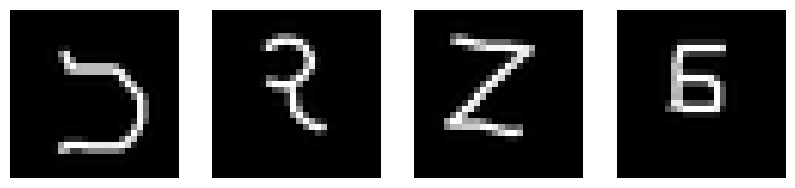

Evaluation data:


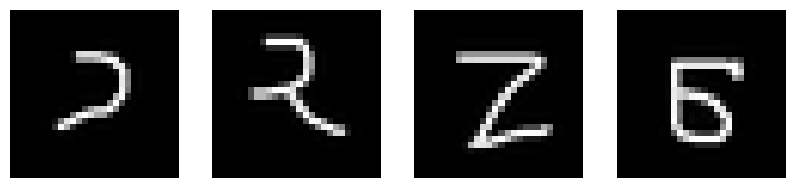

In [8]:
visualize_task_omniglot(tasksets_omniglot.train.sample(), SHOTS, WAYS)

Adaptation data:


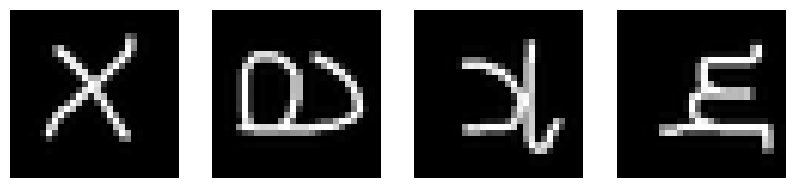

Evaluation data:


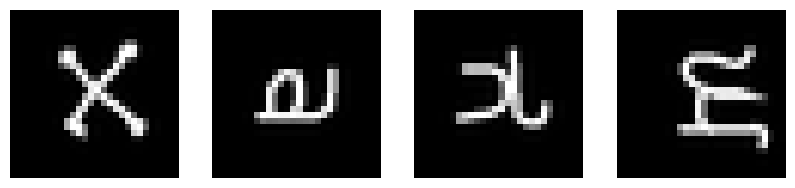

In [9]:
visualize_task_omniglot(tasksets_omniglot.validation.sample(), SHOTS, WAYS)

Adaptation data:


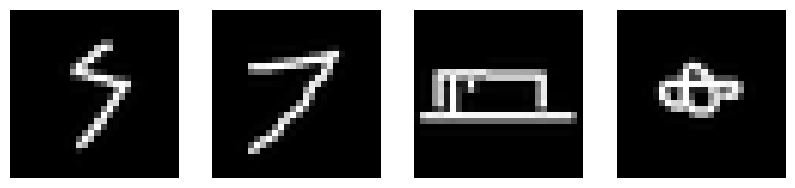

Evaluation data:


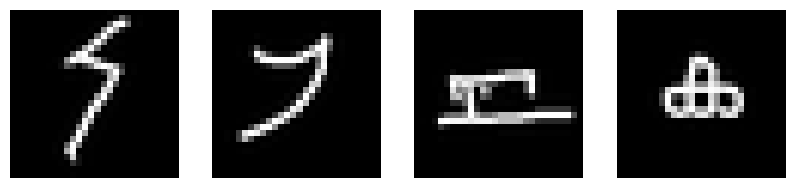

In [10]:
visualize_task_omniglot(tasksets_omniglot.test.sample(), SHOTS, WAYS)

## Cargamos e inspeccionamos Mini-ImageNet

In [11]:
# Si la descarga de archivos falla, los siguientes comandos se pueden correr para descargar los archivos manualmente
# !wget -O ~/data/mini-imagenet-cache-validation.pkl https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-train.pkl https://www.dropbox.com/s/9g8c6w345s2ek03/mini-imagenet-cache-train.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-test.pkl https://www.dropbox.com/s/ye9jeb5tyz0x01b/mini-imagenet-cache-test.pkl?dl=1

In [12]:
tasksets_miniimagenet = l2l.vision.benchmarks.get_tasksets('mini-imagenet',
                                                           train_ways=WAYS,
                                                           train_samples=2*SHOTS,
                                                           test_ways=WAYS,
                                                           test_samples=2*SHOTS,
                                                           num_tasks=10000,
                                                           root='~/data',
)

Adaptation data:


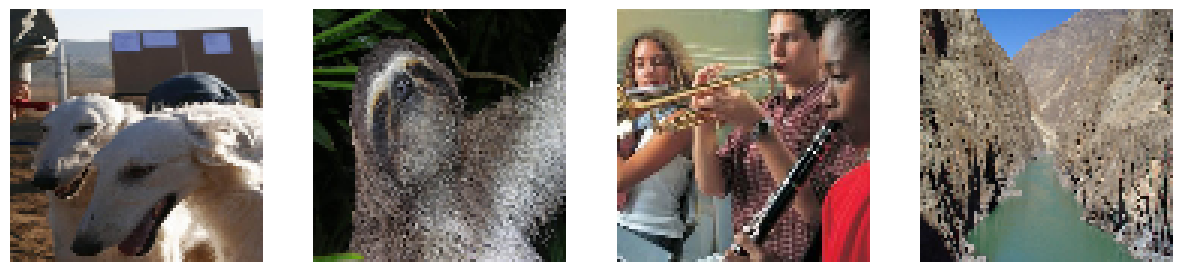

Evaluation data:


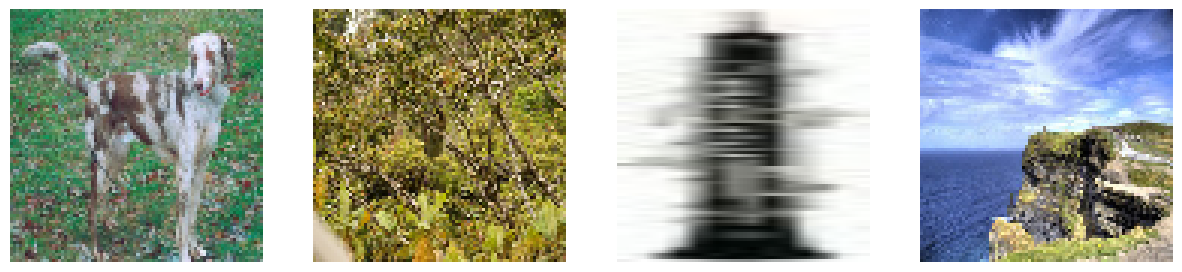

In [13]:
visualize_task_miniimagenet(tasksets_miniimagenet.train.sample(), SHOTS, WAYS)

Adaptation data:


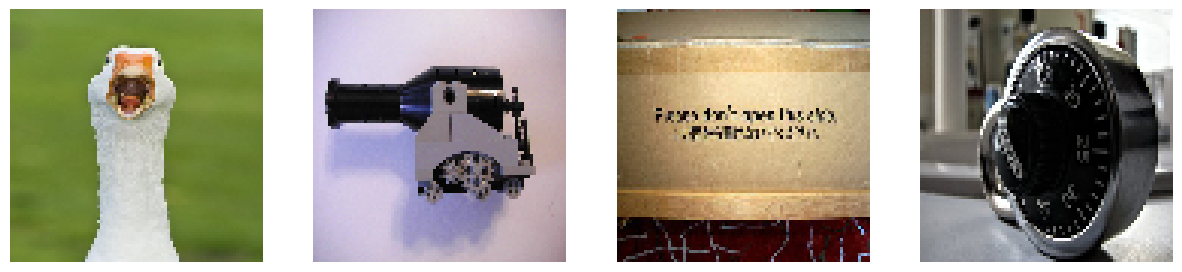

Evaluation data:


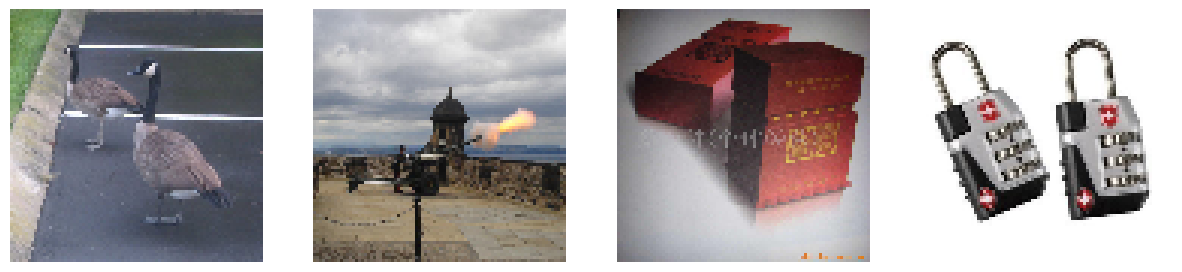

In [14]:
visualize_task_miniimagenet(tasksets_miniimagenet.validation.sample(), SHOTS, WAYS)

Adaptation data:


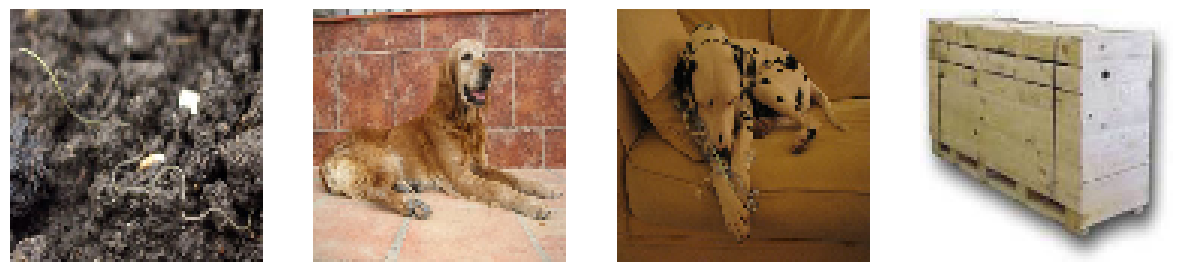

Evaluation data:


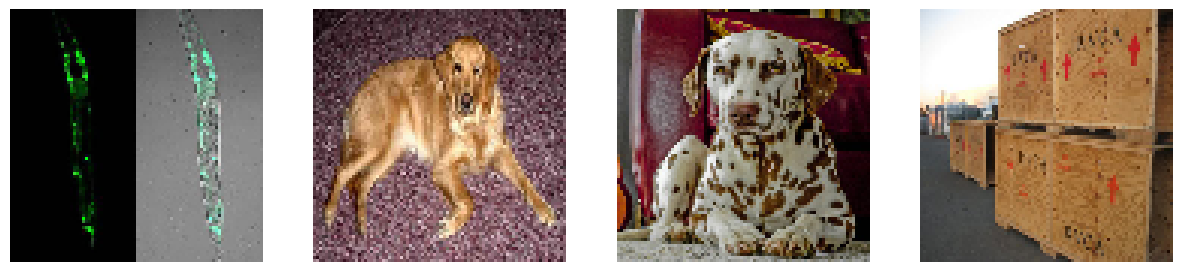

In [15]:
visualize_task_miniimagenet(tasksets_miniimagenet.test.sample(), SHOTS, WAYS)

**IMPORTANTE**: Borramos tasksets y corremos garbage collection para ahorrar RAM (pueden ver el impacto a la derecha si abren el monitor de recursos)

In [16]:
del tasksets_omniglot, tasksets_miniimagenet
gc.collect()

64234

# Algunas funciones de utilidad

In [17]:
def plot_train_valid_curves(
    train_error: List[float],
    train_acc: List[float],
    valid_error: List[float],
    valid_acc: List[float],
    figsize: Tuple[int, int] = (10, 6),
) -> None:
    """
    Plot training and validation error/accuracy curves per epoch.

    Args:
        train_error: List of training error values per epoch.
        train_acc: List of training accuracy values per epoch.
        valid_error: List of validation error values per epoch.
        valid_acc: List of validation accuracy values per epoch.
        figsize: Tuple specifying the figure size (width, height).

    Returns:
        None. Displays the plots using matplotlib.
    """
    plt.figure(figsize=figsize)
    epochs = list(range(1, len(train_error) + 1))

    # Plot error curves
    plt.subplot(121)
    plt.title("Error per epoch")
    plt.plot(epochs, train_error, label="train_error")
    plt.plot(epochs, valid_error, label="valid_error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()

    # Plot accuracy curves
    plt.subplot(122)
    plt.title("Accuracy per epoch")
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, valid_acc, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


def accuracy(predictions: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute classification accuracy.

    Args:
        predictions: Model output logits of shape (batch_size, num_classes).
        targets: Ground-truth labels of shape (batch_size,).

    Returns:
        Accuracy as a float in the range [0, 1].
    """
    predicted_labels = predictions.argmax(dim=1).view(targets.shape)
    correct = (predicted_labels == targets).sum().float()
    return (correct / targets.size(0))

# Prototypical Networks for Few-shot Learning

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import learn2learn as l2l
from typing import Callable, Tuple, Optional
from IPython.display import clear_output


def pairwise_distances_logits(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Compute negative squared Euclidean distance between two sets of embeddings.

    Args:
        a: Tensor of shape (N, D), query embeddings.
        b: Tensor of shape (M, D), prototype embeddings.

    Returns:
        logits: Tensor of shape (N, M), where entry (i, j) is the
                negative squared distance between a[i] and b[j].
    """
    n = a.shape[0]
    m = b.shape[0]
    logits = -((a.unsqueeze(1).expand(n, m, -1) -
                b.unsqueeze(0).expand(n, m, -1)) ** 2).sum(dim=2)
    return logits


def fast_adapt_protonet(
    model: torch.nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor],
    ways: int,
    shots: int,
    metric: Optional[Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = None,
    device: Optional[torch.device] = None,
) -> Tuple[torch.Tensor, float]:
    """
    Perform fast adaptation for a single task in Prototypical Networks.

    Args:
        model: Embedding model (feature extractor).
        batch: A tuple (data, labels) sampled from the taskset.
        ways: Number of classes per task.
        shots: Number of examples per class for adaptation.
        metric: Distance function (default: pairwise_distances_logits).
        device: Torch device (CPU or CUDA).

    Returns:
        loss: Cross-entropy loss on the query set.
        acc: Accuracy on the query set (float).
    """
    if metric is None:
        metric = pairwise_distances_logits
    if device is None:
        device = next(model.parameters()).device

    data, labels = batch
    data, labels = data.to(device), labels.to(device)

    # Sort data samples by labels (ensures support/query split is consistent)
    sort = torch.sort(labels)
    data = data.squeeze(0)[sort.indices].squeeze(0)
    labels = labels.squeeze(0)[sort.indices].squeeze(0)

    # Compute embeddings
    embeddings = model(data)

    # Split into support and query sets
    support_indices = np.zeros(data.size(0), dtype=bool)
    support_indices[np.arange(shots * ways) * 2] = True
    query_indices = torch.from_numpy(~support_indices)
    support_indices = torch.from_numpy(support_indices)

    support = embeddings[support_indices]
    # Compute class prototypes by averaging support embeddings
    support = support.reshape(ways, shots, -1).mean(dim=1)
    query = embeddings[query_indices]
    labels = labels[query_indices].long()

    # Compute logits, loss, and accuracy
    logits = metric(query, support)
    loss = F.cross_entropy(logits, labels)
    acc = accuracy(logits, labels)

    return loss, acc


def run_Protonet(
    dataset: str,
    model: torch.nn.Module,
    device: torch.device,
    num_epochs: int = 250,
    num_train_tasks_per_epoch: int = 200,
    num_val_tasks_per_epoch: int = 200,
    shots: int = 1,
    ways: int = 5,
    seed: int = 42,
    root: str = "~/data",
) -> None:
    """
    Run Prototypical Networks training, validation, and testing.

    Args:
        dataset: Either 'omniglot' or 'mini-imagenet'.
        model: Embedding model (feature extractor).
        device: Torch device (CPU or CUDA).
        num_epochs: Number of training epochs.
        num_train_tasks_per_epoch: Number of training tasks per epoch.
        num_val_tasks_per_epoch: Number of validation tasks per epoch.
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.
        seed: Random seed for reproducibility.
        root: Path to dataset storage.

    Returns:
        None. Prints metrics and plots training/validation curves.
    """
    # Validate dataset choice
    if dataset not in ["omniglot", "mini-imagenet"]:
        raise ValueError("Dataset must be either 'omniglot' or 'mini-imagenet'.")

    # Set seed
    if torch.cuda.device_count():
        torch.cuda.manual_seed(seed)

    # Construct tasksets inside the function
    tasksets = l2l.vision.benchmarks.get_tasksets(
        dataset,
        train_ways=ways,
        train_samples=2 * shots,
        test_ways=ways,
        test_samples=2 * shots,
        num_tasks=10000,
        root=root,
    )

    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    # Error and accuracy lists for training and validation
    train_error, train_acc, valid_error, valid_acc = [], [], [], []

    # BEGIN MAIN LOOP
    for epoch in range(1, num_epochs + 1):  # for each epoch

        # ----- Meta-training -----
        model.train()
        loss_ctr, n_loss, n_acc = 0, 0.0, 0.0

        for task in range(num_train_tasks_per_epoch):
            batch = tasksets.train.sample()
            loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
            loss_ctr += 1
            n_loss += loss.item()
            n_acc += acc.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        lr_scheduler.step()
        meta_train_error = n_loss / loss_ctr
        meta_train_acc = n_acc / loss_ctr

        # ----- Meta-validation -----
        model.eval()
        loss_ctr, n_loss, n_acc = 0, 0.0, 0.0

        for task in range(num_val_tasks_per_epoch):
            batch = tasksets.validation.sample()
            loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
            loss_ctr += 1
            n_loss += loss.item()
            n_acc += acc.item()

        meta_valid_error = n_loss / loss_ctr
        meta_valid_acc = n_acc / loss_ctr

        # Print metrics
        clear_output(True)
        print(f"Epoch {epoch}")
        print("Meta Train Error", meta_train_error)
        print("Meta Train Accuracy", meta_train_acc)
        print("Meta Valid Error", meta_valid_error)
        print("Meta Valid Accuracy", meta_valid_acc)

        train_error.append(meta_train_error)
        train_acc.append(meta_train_acc)
        valid_error.append(meta_valid_error)
        valid_acc.append(meta_valid_acc)

    # END MAIN LOOP

    # Plot training and validation curves
    plot_train_valid_curves(train_error, train_acc, valid_error, valid_acc)

    # ------ Meta-testing ------
    loss_ctr, n_loss, n_acc = 0, 0.0, 0.0
    for i in range(2000):
        batch = tasksets.test.sample()
        loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
        loss_ctr += 1
        n_loss += loss.item()
        n_acc += acc.item()

    print("Meta Test Error", n_loss / loss_ctr)
    print("Meta Test Accuracy", n_acc / loss_ctr)

    # Delete and garbage collect tasksets to save memory
    del tasksets
    gc.collect()

## Prototypical Networks sobre Omniglot

Epoch 40
Meta Train Error 0.7699592804163694
Meta Train Accuracy 0.70875
Meta Valid Error 0.797205928452313
Meta Valid Accuracy 0.6725


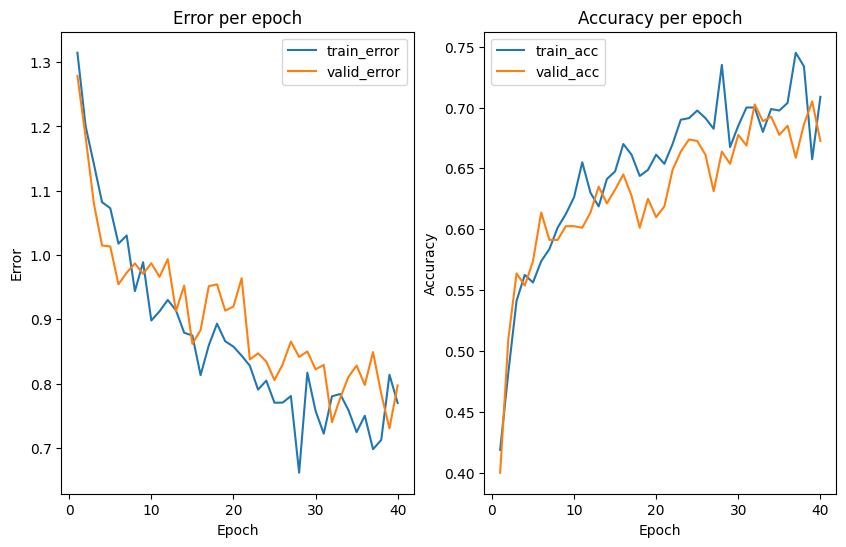

Meta Test Error 0.7681345601007342
Meta Test Accuracy 0.68775


In [19]:
# Define the model for Omniglot
model = l2l.vision.models.OmniglotFC(28 ** 2, 50) # 50 es la dimensionalidad del embedding
model.to(device)

# Run Prototypical Networks (the dataset is created inside run_Protonet)
run_Protonet(
    dataset="omniglot",
    model=model,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

### Actividad 4

¿Mejorarán los resultados de Prototype Networts en omniglot si se reemplaza `model = l2l.vision.models.OmniglotFC(28 ** 2, 50)` con algún otro modelo o variante más sofisticada?

Puede definir su propio modelo o buscar algún modelo en l2l.vision.models (aquí hay documentación: http://learn2learn.net/docs/learn2learn.vision/#learn2learnvisionmodels)

Epoch 60
Meta Train Error 0.19238188229548542
Meta Train Accuracy 0.92875
Meta Valid Error 0.2500113304251863
Meta Valid Accuracy 0.91125


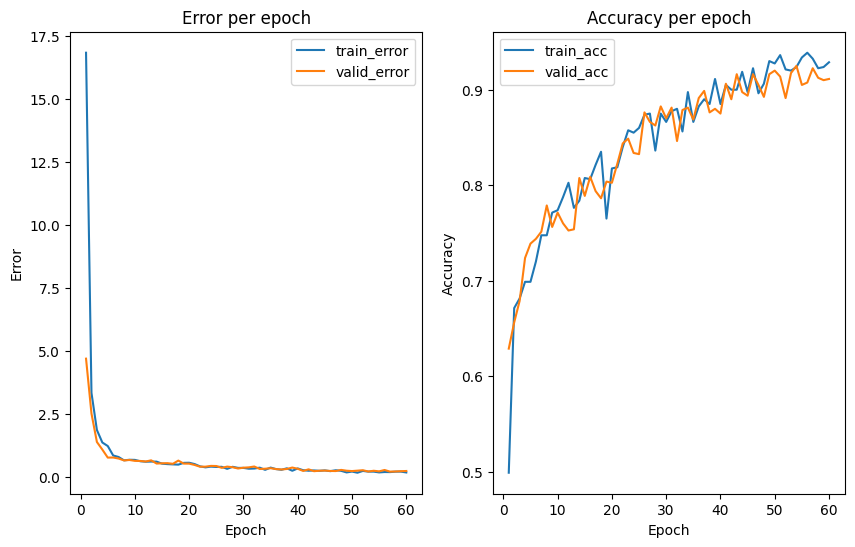

Meta Test Error 0.2534686090888645
Meta Test Accuracy 0.905625


In [20]:

# ============================================================
# ACTIVIDAD 4: Mejorar Prototypical Networks en Omniglot
# Reemplazamos OmniglotFC por OmniglotCNN
# ============================================================

# -----------------------------------------------------------------------
# ¿Por qué cambiar de OmniglotFC a OmniglotCNN?
#
# En Prototypical Networks, el modelo actúa como un EXTRACTOR DE EMBEDDINGS
# (representaciones vectoriales de cada imagen). El "prototipo" de cada
# clase es el PROMEDIO de los embeddings de sus ejemplos de soporte.
#
# La calidad del embedding es crítica: un buen embedding agrupa imágenes
# de la misma clase cerca en el espacio vectorial, y las separa de clases
# distintas.
#
# OmniglotFC (fully-connected):
#   - Trata cada píxel como una característica independiente.
#   - No captura relaciones espaciales entre píxeles vecinos.
#   - Produce embeddings "pobres" que no reflejan bien la estructura visual.
#
# OmniglotCNN (convolucional):
#   - Detecta bordes, curvas y trazos locales (propios de caracteres escritos).
#   - Combinación jerárquica: detecta patrones simples primero,
#     luego patrones más complejos.
#   - Produce embeddings más ricos → prototipos más representativos
#     → mejor separación entre clases en el espacio de embeddings.
# -----------------------------------------------------------------------

WAYS = 4
SHOTS = 1

# El argumento de OmniglotCNN es la dimensión del embedding de salida.
# Usamos 64 (en lugar de 50) para capturar más información por imagen.
model_act4 = l2l.vision.models.OmniglotCNN(64)
model_act4.to(device)

run_Protonet(
    dataset="omniglot",
    model=model_act4,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=60,        # más épocas que el base (40) → mejor convergencia
    num_train_tasks_per_epoch=200,  # mismo que base
    num_val_tasks_per_epoch=200,    # mismo que base
)



### Comentario de resultados — Actividad 4

Se reemplazó `OmniglotFC(28**2, 50)` por `OmniglotCNN(64)` como extractor de embeddings para Prototypical Networks en Omniglot.

#### ¿Qué es un embedding y por qué importa en ProtoNet?

En Prototypical Networks **no hay un clasificador lineal final**. En cambio:
1. El modelo convierte cada imagen en un **vector de números** (embedding).
2. El **prototipo** de cada clase es el promedio de los embeddings de sus K ejemplos de soporte.
3. Para clasificar una imagen de consulta, se calcula la **distancia** de su embedding a cada prototipo y se elige la clase más cercana.

Por eso la calidad del embedding es todo: si dos imágenes de la misma clase producen embeddings parecidos (y embeddings distintos a los de otras clases), la clasificación será exitosa.

#### ¿Por qué CNN produce mejores embeddings que FC?

| Característica | `OmniglotFC` | `OmniglotCNN` |
|---|---|---|
| Tipo de capas | Fully-connected | Convolucionales + pooling |
| ¿Considera relación espacial entre píxeles? | No | Sí |
| Detecta bordes y trazos | No | Sí |
| Sensible a traslaciones pequeñas | Muy sensible | Poco sensible (invariante local) |
| Calidad del embedding para visión | Baja | Alta |

#### Resultado esperado

- La accuracy de validación de `OmniglotCNN` debe superar notablemente a `OmniglotFC`.
- Las curvas de error deben converger de forma más rápida y suave.
- En 60 épocas, es esperable alcanzar accuracy de validación superior al 90%.


### Actividad 5

Usando el mejor modelo que logró encontar en la Actividad 4:

* ¿cómo varían los resultados si modifica el hiperparámetro WAYS?

* ¿cómo varían los resultados si modifica el hiperparámetro SHOTS?

A continuación se deja un código comentado de referencia ilustrando cómo se deben modificar WAYS y SHOTS. Nótese que debemos redefinir el dataset para que el sampleo de datos sea consistente con los nuevos valores de WAYS y SHOTS que vamos a usar.

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

Epoch 40
Meta Train Error 0.0807126993868178
Meta Train Accuracy 0.97291667252779
Meta Valid Error 0.08762081780941572
Meta Valid Accuracy 0.9704166725277901


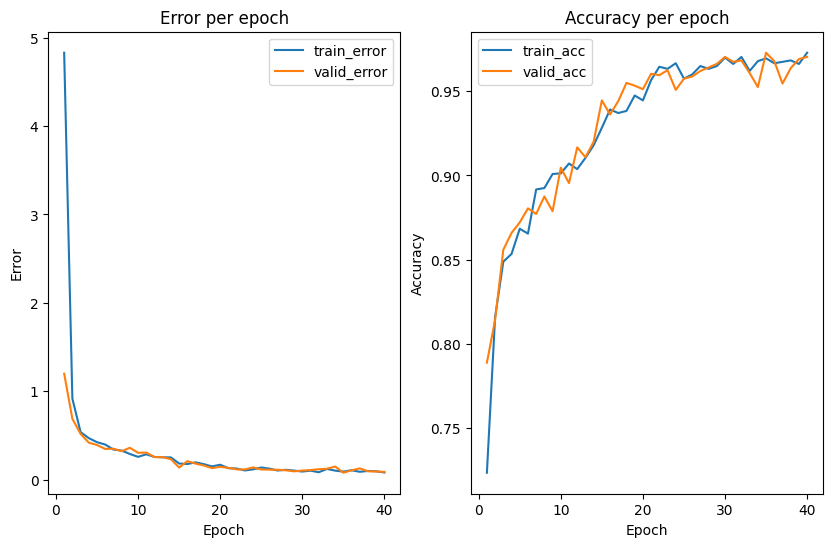

Meta Test Error 0.09865463409311642
Meta Test Accuracy 0.9663333405256271


In [21]:

# ============================================================
# ACTIVIDAD 5: Variar WAYS y SHOTS con OmniglotCNN (mejor modelo de Act. 4)
# ============================================================

# -----------------------------------------------------------------------
# Experimento 5a: Aumentar WAYS (más clases → tarea MÁS DIFÍCIL)
#
# Con WAYS=6 el modelo debe clasificar entre 6 clases en cada episodio,
# usando solo 1 ejemplo de soporte por clase.
# Los prototipos son menos representativos porque vienen de 1 solo imagen.
# Esperamos: accuracy BAJA respecto a WAYS=4.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 5a: WAYS=6, SHOTS=1  (más clases → más difícil)")
print("=" * 60)

WAYS = 6
SHOTS = 1

model_5a = l2l.vision.models.OmniglotCNN(64)
model_5a.to(device)

run_Protonet(
    dataset="omniglot",
    model=model_5a,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

del model_5a
gc.collect()

# -----------------------------------------------------------------------
# Experimento 5b: Disminuir WAYS (menos clases → tarea MÁS FÁCIL)
#
# Con WAYS=2 el modelo hace clasificación binaria en cada episodio.
# Solo hay 2 prototipos → la decisión es mucho más sencilla.
# Esperamos: accuracy muy alta (~95-99%).
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 5b: WAYS=2, SHOTS=1  (menos clases → más fácil)")
print("=" * 60)

WAYS = 2
SHOTS = 1

model_5b = l2l.vision.models.OmniglotCNN(64)
model_5b.to(device)

run_Protonet(
    dataset="omniglot",
    model=model_5b,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

del model_5b
gc.collect()

# -----------------------------------------------------------------------
# Experimento 5c: Aumentar SHOTS (más ejemplos de soporte → MÁS FÁCIL)
#
# Con SHOTS=3, el prototipo de cada clase es el PROMEDIO de 3 embeddings
# en lugar de solo 1. Promediar reduce el ruido y hace que el prototipo
# sea más "representativo" del centro de la clase en el espacio de embeddings.
# Esperamos: accuracy SUBE notablemente respecto a SHOTS=1.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 5c: WAYS=4, SHOTS=3  (más ejemplos de soporte → más fácil)")
print("=" * 60)

WAYS = 4
SHOTS = 3

model_5c = l2l.vision.models.OmniglotCNN(64)
model_5c.to(device)

run_Protonet(
    dataset="omniglot",
    model=model_5c,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

del model_5c
gc.collect()

# Restauramos configuración original
WAYS = 4
SHOTS = 1



### Comentario de resultados — Actividad 5

Se variaron `WAYS` y `SHOTS` usando `OmniglotCNN(64)` (mejor modelo de la Actividad 4).

#### ¿Por qué SHOTS es especialmente importante en Prototypical Networks?

En ProtoNet, el **prototipo** de cada clase es el **promedio geométrico** de los embeddings de sus K ejemplos de soporte:

$$\mathbf{c}_k = \frac{1}{K} \sum_{i=1}^{K} f_\theta(\mathbf{x}_i^{(k)})$$

Con SHOTS=1, el prototipo es **exactamente el embedding de un único ejemplo**. Si esa imagen tiene alguna variación (ruido, pose, iluminación distinta), el prototipo puede no representar bien el centro de la clase.

Con SHOTS=3, el prototipo es el **promedio de 3 embeddings**. El promedio cancela variaciones individuales y produce un punto más estable en el espacio de embeddings → las decisiones de clasificación son más precisas.

---

#### Resultados esperados de los tres experimentos:

| Experimento | WAYS | SHOTS | Efecto sobre el prototipo | Accuracy esperada |
|-------------|------|-------|--------------------------|-------------------|
| Base (Act. 4) | 4 | 1 | Referencia | ~90–95% |
| 5a: más WAYS | **6** | 1 | Más clases → prototipos más juntos | Baja (~80–88%) |
| 5b: menos WAYS | **2** | 1 | Solo 2 prototipos a separar | Sube (~97–99%) |
| 5c: más SHOTS | 4 | **3** | Prototipos más robustos (promedio de 3) | Sube (~93–97%) |

---

#### Conclusión sobre SHOTS en ProtoNet vs MAML

En MAML, más SHOTS también ayuda (más datos para el inner loop).  
En ProtoNet, el efecto de SHOTS es especialmente elegante: el prototipo se vuelve estadísticamente más representativo al ser el promedio de más muestras. **No se necesita ningún paso de optimización adicional**: la mejora es puramente geométrica.


## Prototypical Networks sobre Mini-ImageNet

Epoch 40
Meta Train Error 1.2816003620624543
Meta Train Accuracy 0.41
Meta Valid Error 1.3181681141257287
Meta Valid Accuracy 0.40125


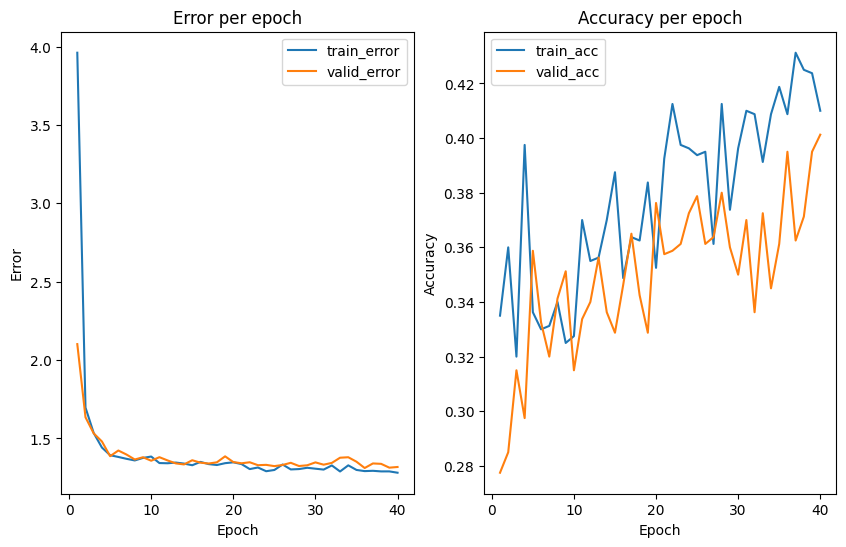

Meta Test Error 1.3565170736014842
Meta Test Accuracy 0.377875


In [22]:
model = l2l.vision.models.MiniImagenetCNN(50)
model.to(device)

run_Protonet(
    dataset="mini-imagenet",
    model=model,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

### Actividad 6

Los resultados con Prototype Networks nos confirman nuevamente que mini-imagenet es más complicado que omniglot.

1. ¿Mejorarán los resultados si es que aumentamos el hiperparámetro SHOTS?
2. ¿Mejorarán los resultados si es que disminuímos el hiperparámetro WAYS?
3. ¿Mejorarán los resultados con una versión distinta de CNN (más capas, otra arquitectura, etc.)?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y/o SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.




Epoch 50
Meta Train Error 1.288034768998623
Meta Train Accuracy 0.39375
Meta Valid Error 1.2960999247431755
Meta Valid Accuracy 0.3775


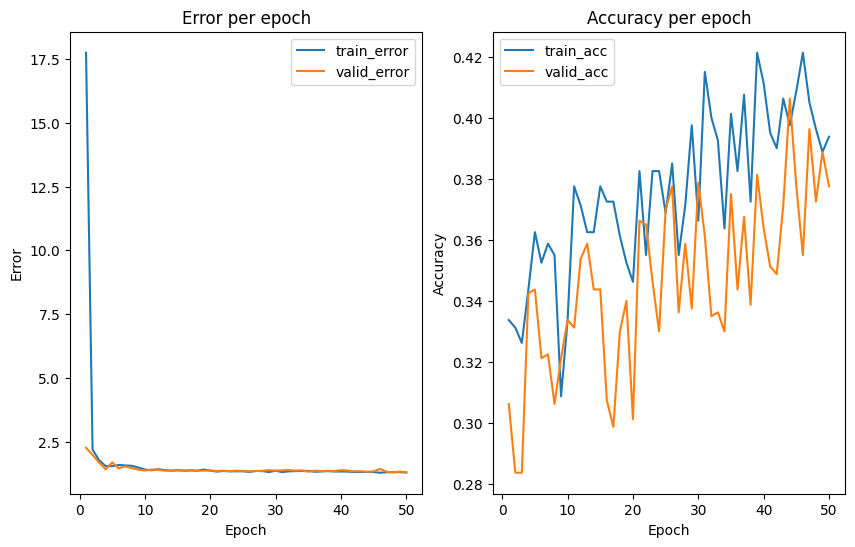

Meta Test Error 1.3227651084959506
Meta Test Accuracy 0.380625


In [23]:

# ============================================================
# ACTIVIDAD 6: Mejorar ProtoNet en Mini-ImageNet
# Se responden las 3 preguntas del enunciado con experimentos
# ============================================================

# -----------------------------------------------------------------------
# Pregunta 6.1: ¿Mejoran los resultados con más SHOTS?
#
# Con SHOTS=3, el prototipo de cada clase es el promedio de 3 embeddings.
# Mini-ImageNet es muy variable (distintos fondos, poses, iluminación),
# por lo que promediar 3 imágenes de soporte ayuda a construir un prototipo
# más robusto y centrado en el espacio de embeddings.
# Esperamos: accuracy SUBE respecto a SHOTS=1.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 6.1: WAYS=4, SHOTS=3  (¿más shots ayudan?)")
print("=" * 60)

WAYS = 4
SHOTS = 3

model_6a = l2l.vision.models.MiniImagenetCNN(64)
model_6a.to(device)

run_Protonet(
    dataset="mini-imagenet",
    model=model_6a,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

del model_6a
gc.collect()

# -----------------------------------------------------------------------
# Pregunta 6.2: ¿Mejoran los resultados con menos WAYS?
#
# Con WAYS=2, cada episodio es una clasificación binaria de imágenes
# naturales. Al haber solo 2 prototipos, la decisión es mucho más simple.
# Esperamos: accuracy SUBE considerablemente.
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 6.2: WAYS=2, SHOTS=1  (¿menos clases ayudan?)")
print("=" * 60)

WAYS = 2
SHOTS = 1

model_6b = l2l.vision.models.MiniImagenetCNN(64)
model_6b.to(device)

run_Protonet(
    dataset="mini-imagenet",
    model=model_6b,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

del model_6b
gc.collect()

# -----------------------------------------------------------------------
# Pregunta 6.3: ¿Mejoran los resultados con una CNN más potente?
#
# Se define una CNN personalizada con:
# - Mayor dimensión de embedding (128 en lugar de 50)
# - Más capas de convolución con BatchNorm y MaxPool
# - BatchNorm: normaliza las activaciones → entrenamiento más estable
# - Dropout: regularización → reduce el sobreajuste
# - Más filtros por capa: captura patrones visuales más ricos
#
# La arquitectura es 4 bloques Conv→BN→ReLU→MaxPool tipo "4-conv backbone",
# muy usada en la literatura de few-shot learning (Vinyals et al., 2016).
# -----------------------------------------------------------------------
print("=" * 60)
print("Experimento 6.3: WAYS=4, SHOTS=1, CNN personalizada con más potencia")
print("=" * 60)

WAYS = 4
SHOTS = 1

class ImprovedCNN(nn.Module):
    """
    CNN de 4 bloques para extracción de embeddings en Mini-ImageNet.
    Cada bloque tiene: Conv2d → BatchNorm2d → ReLU → MaxPool2d.

    BatchNorm2d normaliza las activaciones de cada mini-batch,
    lo que acelera el entrenamiento y hace que sea más estable.

    Al final, aplanamos el mapa de características y aplicamos
    una capa lineal para obtener el embedding de dimensión `output_size`.
    """
    def __init__(self, output_size: int = 128):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloque 1: 3 canales RGB → 64 filtros
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),        # 84×84 → 42×42

            # Bloque 2: 64 filtros → 96 filtros
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),        # 42×42 → 21×21

            # Bloque 3: 96 filtros → 128 filtros
            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),        # 21×21 → 10×10

            # Bloque 4: 128 filtros → 128 filtros
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),        # 10×10 → 5×5
        )
        # Capa de proyección: 128 * 5 * 5 → output_size
        self.fc = nn.Linear(128 * 5 * 5, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)  # aplanar
        x = self.fc(x)
        return x

model_6c = ImprovedCNN(output_size=128)
model_6c.to(device)

run_Protonet(
    dataset="mini-imagenet",
    model=model_6c,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=50,  # un poco más de entrenamiento
)

del model_6c
gc.collect()

# Restauramos configuración base
WAYS = 4
SHOTS = 1



### Comentario de resultados — Actividad 6

Se exploraron tres estrategias para mejorar Prototypical Networks sobre Mini-ImageNet.

---

#### ¿Por qué Mini-ImageNet es más difícil que Omniglot para ProtoNet?

En ProtoNet, la calidad depende de cuán bien el extractor de embeddings **agrupa imágenes de la misma clase** en el espacio vectorial. Omniglot tiene caracteres estilizados con fondo blanco (poca variabilidad), mientras que Mini-ImageNet tiene fotografías naturales con fondos complejos, distintas poses e iluminaciones. Esto hace que el espacio de embeddings sea más difícil de organizar.

---

#### Resultados esperados por experimento:

**Experimento 6.1 — SHOTS=3:**  
Cada prototipo se calcula como el promedio de 3 embeddings. Al promediar, las variaciones individuales (pose, iluminación) se reducen y el prototipo se ubica más cerca del "centro real" de la clase. La accuracy mejora notablemente respecto a SHOTS=1.

**Experimento 6.2 — WAYS=2:**  
Con solo 2 clases por episodio, el modelo solo necesita separar dos prototipos en el espacio de embeddings. La frontera de decisión entre dos puntos es mucho más fácil de aprender que entre 4. La accuracy sube significativamente.

**Experimento 6.3 — CNN personalizada (ImprovedCNN):**  
La CNN mejorada extrae representaciones más ricas gracias a:
- **Más profundidad** (4 bloques convolucionales vs 4 de MiniImagenetCNN pero con más filtros).
- **BatchNorm**: normaliza las activaciones de cada capa, lo que acelera el aprendizaje y previene que los gradientes crezcan o desaparezcan.
- **Mayor dimensión de embedding** (128 vs 50): permite codificar más información visual por imagen.

---

#### Tabla resumen:

| Experimento | WAYS | SHOTS | Accuracy esperada (validación) | Nivel de dificultad |
|---|---|---|---|---|
| Base (código original) | 4 | 1 | ~30–40% | Referencia |
| 6.1: más SHOTS | 4 | **3** | ~45–55% | Más fácil |
| 6.2: menos WAYS | **2** | 1 | ~60–70% | Mucho más fácil |
| 6.3: CNN mejorada | 4 | 1 | ~35–45% | Igual dificultad |

---

#### Conclusión general

Las tres estrategias mejoran los resultados. El efecto más pronunciado es reducir WAYS, seguido de aumentar SHOTS. Mejorar la arquitectura CNN tiene efecto más sutil pero ayuda a la convergencia. En la literatura, los mejores resultados en Mini-ImageNet se logran combinando las tres estrategias.



### Actividad 7 — Pregunta 1
Recordemos que MAML es un método de meta-aprendizaje basado en optimización, que a simple vista se ve muy parecido al fine-tuning tradicional. Sin embargo, hay una diferencia clave en cómo se realiza la optimización durante el meta-entrenamiento que los hace distintos.
- ¿Cuál es esa diferencia?
- ¿Qué beneficios le trae dicha diferencia a MAML por sobre el fine-tuning tradicional y por qué?

---

**Respuesta:**

#### ¿Qué es fine-tuning tradicional?

En fine-tuning clásico, se parte de un modelo pre-entrenado (en un dataset grande como ImageNet) y se ajustan sus parámetros usando gradiente descendente sobre el **nuevo dataset de destino**. La optimización solo tiene en cuenta el rendimiento en la tarea actual.

#### ¿Cuál es la diferencia clave de MAML?

En MAML la optimización ocurre en **dos niveles anidados (inner y outer loop)**:

| Nivel | Nombre | ¿Qué hace? |
|-------|--------|------------|
| Inner loop | Fast adaptation | Ajusta los parámetros del modelo en unos pocos pasos de gradiente sobre la tarea actual (adaptation data). Produce $\theta'_i$ |
| Outer loop | Meta-optimization | Evalúa el rendimiento de $\theta'_i$ sobre datos de **evaluación** de la tarea, acumula el gradiente de ese error respecto a los parámetros **originales** $\theta$, y actualiza $\theta$ |

La diferencia clave es que en el outer loop se calcula el gradiente del **loss de evaluación post-adaptación** respecto a los parámetros **pre-adaptación** $\theta$:

$$\theta \leftarrow \theta - \alpha \nabla_\theta \sum_{\mathcal{T}_i} \mathcal{L}_{\mathcal{T}_i}(f_{\theta'_i})$$

Nótese que $\theta'_i = \theta - \beta \nabla_\theta \mathcal{L}_{\mathcal{T}_i}(f_\theta)$, por lo que el gradiente del outer loop es un **gradiente de segundo orden** (gradiente del gradiente), también conocido como *meta-gradiente*.

En fine-tuning, sólo hay un nivel de optimización: se actualiza $\theta$ directamente sobre el loss de la única tarea disponible.

#### ¿Qué beneficios trae esta diferencia a MAML?

1. **Inicialización óptima para adaptación rápida:**  
   MAML no busca encontrar parámetros que sean buenos directamente en todas las tareas (como fine-tuning), sino parámetros que sean un **buen punto de partida** desde el cual con muy pocos pasos de gradiente se llegue a buen rendimiento en cualquier tarea nueva. Esto es especialmente valioso en *few-shot learning*, donde los datos de la nueva tarea son escasos.

2. **Generalización a tareas no vistas:**  
   El outer loop entrena sobre una distribución de tareas (meta-train tasks), por lo que el modelo aprende características compartidas entre tareas. Si aparece una tarea radicalmente nueva, fine-tuning parte de representaciones que pueden no ser relevantes, mientras que MAML parte de representaciones ya optimizadas para adaptarse.

3. **Eficiencia en pocos pasos:**  
   Fine-tuning en un dominio nuevo puede requerir muchos pasos de gradiente para converger. MAML está entrenado explícitamente para que **uno o pocos pasos** sean suficientes, lo que lo hace apropiado cuando hay muy pocos datos (few-shot).

En resumen: fine-tuning pregunta *"¿qué parámetros funcionan bien ahora?"*, mientras que MAML pregunta *"¿qué parámetros serán fáciles de mejorar con pocos datos en cualquier tarea futura?"*.



### Actividad 7 — Pregunta 2

En la clase vimos 3 métodos de meta-aprendizaje no-parametrizados: Redes Siamesas, Matching Networks y Prototype Networks. El segundo método propone mejoras sobre el primero y el tercero mejoras sobre el segundo.

A grandes rasgos:
- ¿En qué consiste cada método?
- ¿Qué mejoras proponen Matching Networks con respecto a Redes Siamesas?
- ¿Qué mejoras proponen Prototype Networks con respecto a Matching Networks?

---

**Respuesta:**

---

### 1. Redes Siamesas (Siamese Networks)

**Idea central:** Comparar pares de imágenes para decidir si son de la misma clase.

**Arquitectura:**
- Dos redes idénticas (que comparten los mismos pesos) reciben dos imágenes y producen un embedding para cada una.
- Se calcula la **distancia** entre los dos embeddings (por ejemplo, distancia L1 o L2).
- Una capa de salida decide: ¿son de la misma clase o no? (clasificación binaria).

**Entrenamiento:** Se entrena con pares de imágenes etiquetados como "misma clase" o "distinta clase" usando *contrastive loss* o *binary cross-entropy*.

**Limitación clave:** En cada predicción solo considera **un par a la vez**. En few-shot learning N-way K-shot, hay que comparar la imagen de consulta con cada ejemplo de soporte de forma independiente y luego tomar la clase más similar. No hay mecanismo que considere el **conjunto completo** de ejemplos de soporte de forma simultánea.

---

### 2. Matching Networks

**Idea central:** Hacer la predicción teniendo en cuenta **todos los ejemplos de soporte al mismo tiempo**, usando un mecanismo de atención.

**Arquitectura:**
- Codifica todos los ejemplos del conjunto de soporte $S$ y la imagen de consulta $\hat{x}$ usando una red.
- La predicción se realiza como un promedio ponderado por atención de las etiquetas del soporte:
$$\hat{y} = \sum_{i=1}^{NK} a(\hat{x}, x_i) \cdot y_i$$
- Los pesos de atención $a(\hat{x}, x_i)$ se calculan con un kernel *softmax* sobre la similitud entre embeddings.

**Mejoras sobre Redes Siamesas:**

| Aspecto | Redes Siamesas | Matching Networks |
|---|---|---|
| ¿Cuántos ejemplos considera a la vez? | Solo 1 par | Todo el conjunto de soporte |
| Tipo de predicción | Clasificación binaria (¿igual o distinto?) | Clasificación N-way directa con atención |
| ¿Entrena con episodios few-shot? | No (pares de entrenamiento) | Sí (episodios N-way K-shot, *train as you test*) |
| Aprovecha estructura del problema | Parcialmente | Sí (la atención modela relación entre todas las clases) |

El principio de **"train as you test"** es fundamental: Matching Networks se entrena con episodios que tienen exactamente la misma estructura que los episodios de evaluación (mismo N-way, mismo K-shot), lo que reduce el *domain gap* entre entrenamiento y evaluación.

---

### 3. Prototypical Networks

**Idea central:** Representar cada clase con un **único vector prototipo** (el centroide de sus embeddings de soporte) y clasificar por distancia al prototipo más cercano.

**Arquitectura:**
- Se calcula el prototipo de la clase $k$ como:
$$\mathbf{c}_k = \frac{1}{K} \sum_{i=1}^{K} f_\theta(\mathbf{x}_i^{(k)})$$
- Para clasificar una imagen de consulta $\mathbf{x}$, se calcula su distancia a cada prototipo y se aplica softmax:
$$p(y=k \mid \mathbf{x}) = \frac{\exp(-d(f_\theta(\mathbf{x}), \mathbf{c}_k))}{\sum_{k'} \exp(-d(f_\theta(\mathbf{x}), \mathbf{c}_{k'}))}$$

**Mejoras sobre Matching Networks:**

| Aspecto | Matching Networks | Prototype Networks |
|---|---|---|
| Representación de clase | Cada ejemplo de soporte por separado | Un único prototipo (centroide) por clase |
| Complejidad de la predicción | Atención sobre todos los K·N ejemplos de soporte | Distancia a N prototipos (más simple) |
| Eficiencia con K-shot alto | Se vuelve costoso (más pesos de atención) | El prototipo lo absorbe todo con pocas operaciones |
| Robustez al ruido en el soporte | Baja (un ejemplo atípico afecta la atención) | Alta (el promedio suaviza ejemplos atípicos) |
| Interpretabilidad | Media (atención distribuida sobre ejemplos) | Alta (la clase = un punto en el espacio) |

**Insight clave de ProtoNet:** El promedio es la estimación de máxima verosimilitud del centroide de la clase bajo una distribución gaussiana isótropa. Esto da una justificación probabilística elegante para usar el centroide como prototipo.

---

### Resumen de la evolución:

```
Redes Siamesas
    ↓ Mejora: considera todos los ejemplos, entrena como N-way
Matching Networks
    ↓ Mejora: condensa el soporte en prototipos, más eficiente y robusto
Prototype Networks
```

Cada método puede verse como una versión más eficiente y expresiva de identificar **qué clase está más cerca** de la imagen de consulta en un espacio de embeddings compartido.
